# Run Water Fraction Experiments

Group A – Baseline Quality Filtering<br>
* A1 – No filtering: All available pixels retained.
* A2 – Bad pixels removed.
* A3 – Bad + degraded pixels removed.
* A4 – Bad + degraded + suspicious pixels removed (most restrictive).

Group B – Alternative Filtering Approaches
* B1 – Default filtering: Using the general quality flag.
* B2 – Bitwise filtering: Bad pixels were removed ignoring the no_pixels bitwise flag.
* B3 – Geometric inner-swath exclusion: Pixels inside ±10 km of nadir removed by a geometric approach, instead of using the inner_swath flag.
* B4 – Combined filtering: Applying bitwise and geometric filters jointly.


## Imports

In [1]:
%load_ext autoreload
%autoreload 2

from tqdm.auto import tqdm

import pickle

from swot_toolkit.swot import create_raster_mosaic_combined
from swot_toolkit.analysis import open_sites_and_dates
from swot_toolkit.pipe2 import open_output_dir, open_roi
from swot_toolkit.pipe4 import calc_swot_metrics, open_datasets, quality_flags_bad
from swot_toolkit.water_frac import WaterFraction
from swot_toolkit.flags import Scenarios


In [2]:
sites_dates = open_sites_and_dates("/data/swot/output")
sites_dates

{'Curua-Una': ['2024-07-13', '2025-08-14'],
 'Northeast': ['2024-05-29', '2025-07-20'],
 'Rio_Branco': ['2024-04-03', '2025-09-07'],
 'Rio_Madeira': ['2024-08-21', '2025-07-21'],
 'Rio_Negro': ['2024-11-29', '2025-08-07']}

In [3]:
water_frac = WaterFraction("Curua-Una", "2024-07-13")

Reading KML file: /data/swot/output/Curua-Una/kml/Curua-Una.kml


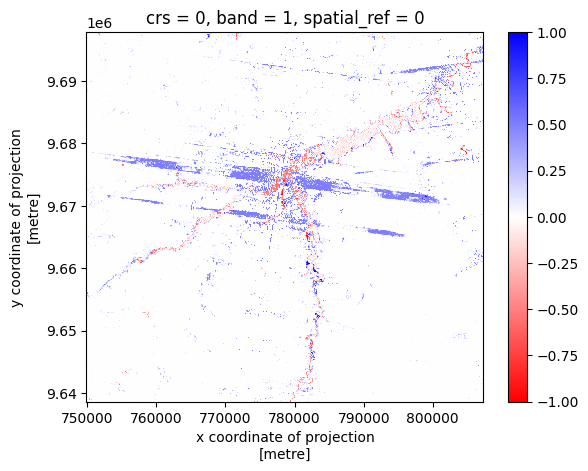

In [73]:
residuals = water_frac.template - water_frac.ref_mask()
residuals.plot(cmap="bwr_r")

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
water_frac.clear_cache()
swot, patches = water_frac.swot(Scenarios.A.BAD_DEG_SUSP_REMOVED, Scenarios.B.BITWISE)

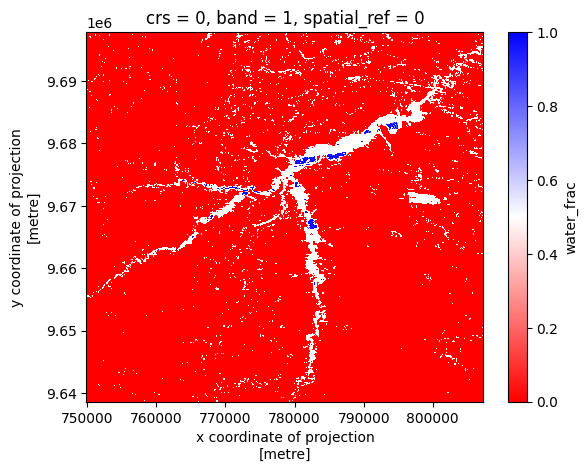

In [80]:
swot.plot(cmap="bwr_r")

In [82]:
residuals = swot - water_frac.ref_mask()

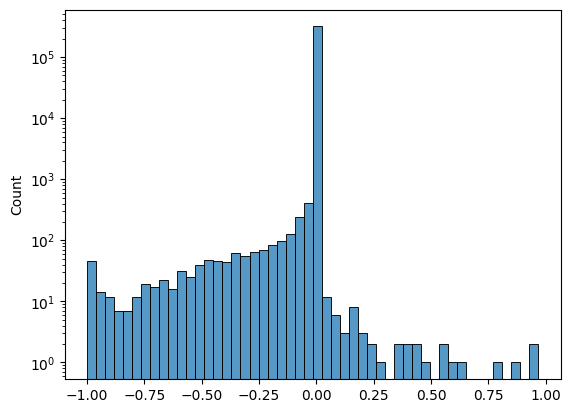

In [90]:
fig, ax = plt.subplots()
sns.histplot(residuals.to_numpy().flatten(), bins=50, log_scale=(False, False), kde=False, ax=ax)
ax.set_yscale("log", nonpositive="clip")

In [ ]:
def get_valid_pairs(raster, ref_mask):
    ref = np.asarray(ref_mask).squeeze().astype(np.float16)
    sat = np.asarray(raster).squeeze().astype(np.float16)

    if ref.shape != sat.shape:
        raise ValueError(f"Shape mismatch: ref={ref.shape}, sat={sat.shape}")

    ref = ref.ravel()
    sat = sat.ravel()

    # Fill sat values as no water. This allows us to keep pixels where ref is valid but sat is not,
    # which is important for bias calculation.
    sat = np.nan_to_num(sat, nan=0)
    sat[sat > 1] = 1
    sat[sat < 0] = 0

    mask = np.isfinite(ref) & np.isfinite(sat)
    mask &= (ref > 0) | (sat > 0)
    # mask &= (ref < 1) | (sat < 1)
    # & (ref >= 0) & (ref <= 1) & (sat >= 0) & (sat <= 1)

    return ref[mask], sat[mask]

residuals_dict = {}
for scenario in Scenarios:
    swot, patches = water_frac.swot(scenario.a, scenario.b)

    swot_valid, ref_valid = get_valid_pairs(swot, water_frac.ref_mask())
    residuals_dict[scenario.a, scenario.b] = swot_valid - ref_valid


In [115]:
data = []
labels = []
for sc_a in Scenarios.A:
    for sc_b in Scenarios.B:
        if sc_a is Scenarios.A.NO_FILTERING and sc_b is not Scenarios.B.DEFAULT:
            continue

        data.append(residuals_dict[sc_a, sc_b])
        labels.append(f"{sc_a.name}, {sc_b.name}")

        print(f"{sc_a.name}, {sc_b.name}: {residuals_dict[sc_a, sc_b].mean():.4f}")

NO_FILTERING, DEFAULT: -0.0880
BAD_REMOVED, DEFAULT: -0.1736
BAD_REMOVED, BITWISE: -0.0911
BAD_REMOVED, GEOMETRIC: -0.0817
BAD_REMOVED, BITWISE_GEOMETRIC: -0.0417
BAD_DEG_REMOVED, DEFAULT: -0.1736
BAD_DEG_REMOVED, BITWISE: -0.0911
BAD_DEG_REMOVED, GEOMETRIC: -0.0817
BAD_DEG_REMOVED, BITWISE_GEOMETRIC: -0.0417
BAD_DEG_SUSP_REMOVED, DEFAULT: 0.6177
BAD_DEG_SUSP_REMOVED, BITWISE: 0.6177
BAD_DEG_SUSP_REMOVED, GEOMETRIC: 0.6182
BAD_DEG_SUSP_REMOVED, BITWISE_GEOMETRIC: 0.6187


In [117]:
data.reverse()
labels.reverse()

/tmp/ipykernel_65497/1157823185.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plot = ax.boxplot(data, labels=labels, vert=False, showfliers=False)


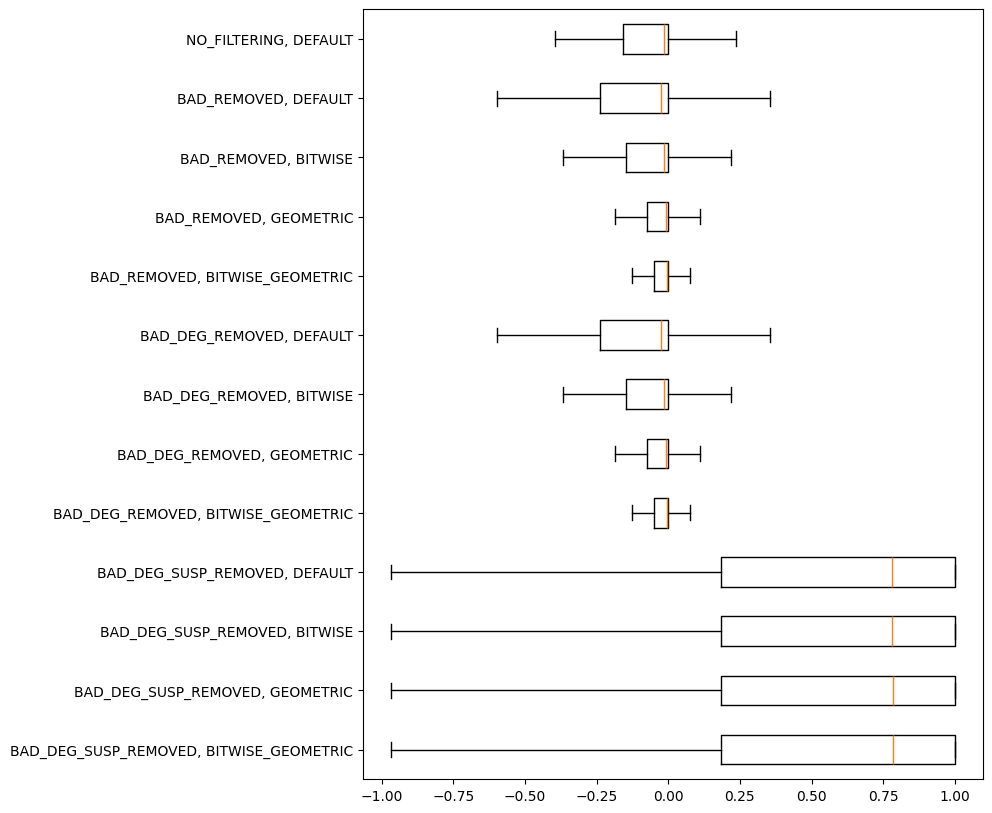

In [121]:
fig, ax = plt.subplots(figsize=(8, 10))
plot = ax.boxplot(data, labels=labels, vert=False, showfliers=False)

In [81]:
residuals = swot - water_frac.ref_mask()

## Experiment with 1 site 

In [6]:
sites_dates = open_sites_and_dates("/data/swot/output")
sites_dates

{'Curua-Una': ['2024-07-13', '2025-08-14'],
 'Northeast': ['2024-05-29', '2025-07-20'],
 'Rio_Branco': ['2024-04-03', '2025-09-07'],
 'Rio_Madeira': ['2024-08-21', '2025-07-21'],
 'Rio_Negro': ['2024-11-29', '2025-08-07']}

In [7]:
REGION = "Curua-Una"
DATE = "2025-08-14"

In [235]:
datasets = open_datasets(REGION, DATE, s2=False, ref=True, opera_s2=False, opera_s1=False)

In [236]:
datasets.keys()

dict_keys(['ref_mask'])

In [246]:
base_dir, aoi, mosaic_df = open_roi(REGION)
params = get_filtering_params("Bad removed", "Bitwise filtering")

raster, patches, no_data_masks = create_raster_mosaic_combined(
    mosaic_df=mosaic_df,
    ref_date=DATE,
    aoi=aoi,
    **params,
)

# raster = process_swot_mask(raster, water_threshold=0.6)
# raster.plot()

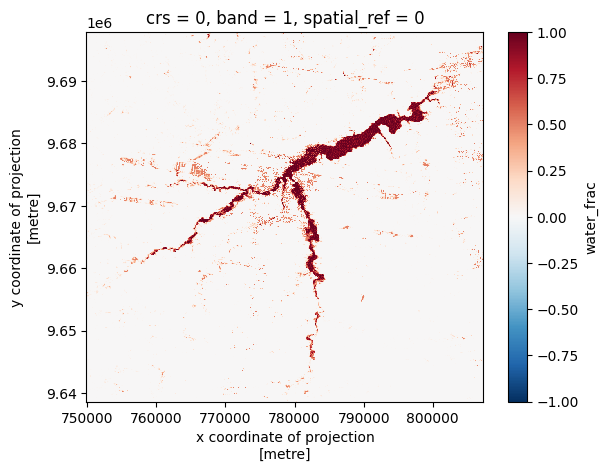

In [247]:
raster.plot()

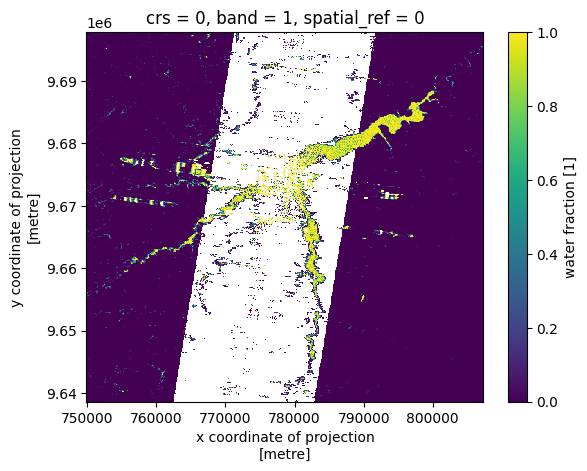

In [248]:
patches[0]["water_frac"].plot()

In [ ]:
sns.histplot()

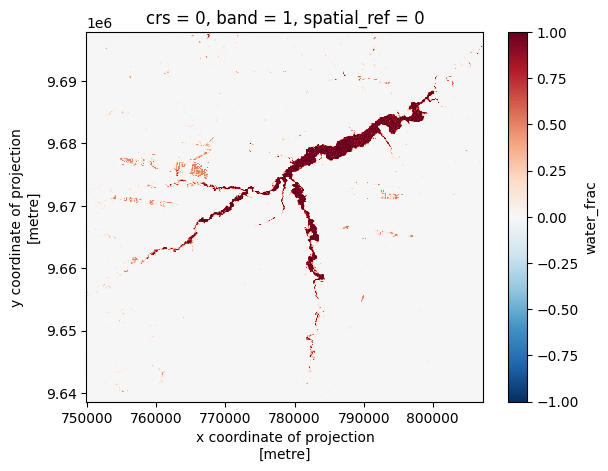

In [53]:
raster.plot()

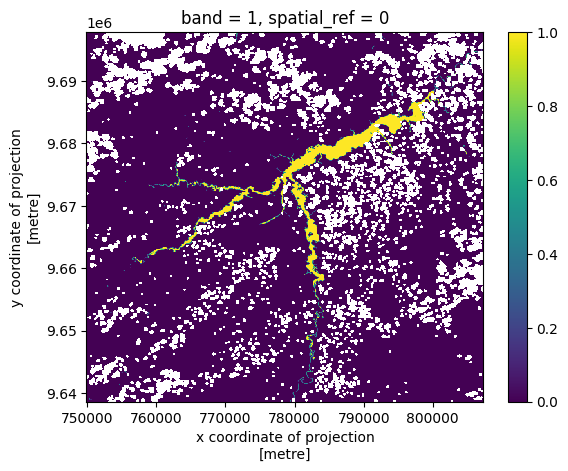

In [80]:
from rasterio.enums import Resampling

ref_mask = datasets["ref_mask"]
ref_mask = ref_mask.where(ref_mask != 2)
ref_water_fraction = ref_mask.rio.reproject_match(raster, resampling=Resampling.average)
ref_water_fraction.plot()

N valid pixels: 269284
Bias (sat - ref): -0.0003


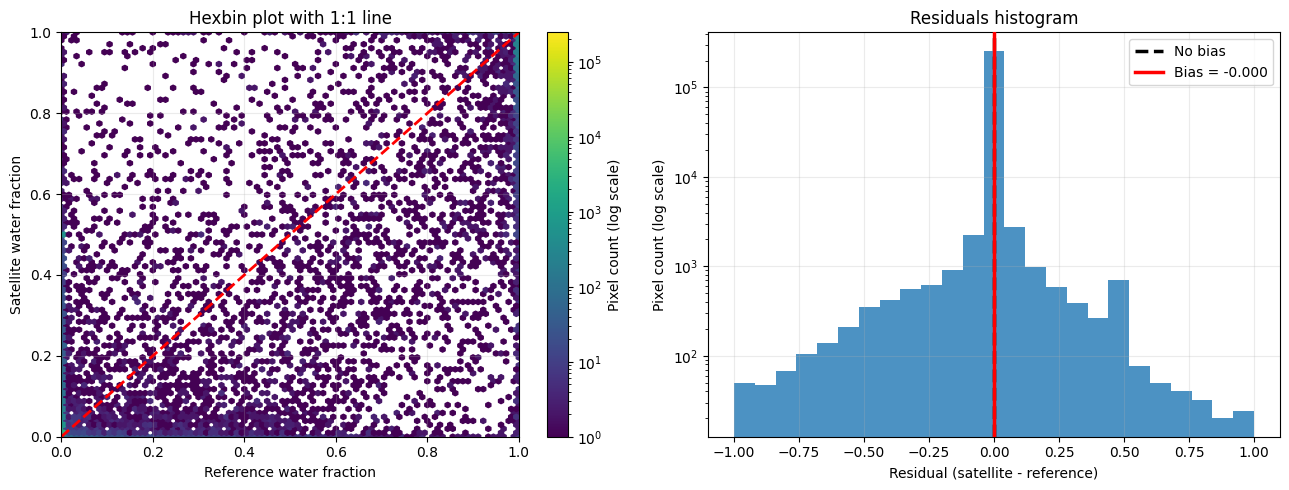

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Convert to NumPy and flatten ---
ref = np.asarray(ref_water_fraction).squeeze()
sat = np.asarray(raster).squeeze()

if ref.shape != sat.shape:
    raise ValueError(f"Shape mismatch: ref={ref.shape}, sat={sat.shape}")

ref_flat = ref.ravel()
sat_flat = sat.ravel()

# --- 2. Keep only valid pixels ---
mask = (
    np.isfinite(ref_flat)
    & np.isfinite(sat_flat)
    & ~np.isnan(ref_flat)
    & ~np.isnan(sat_flat)
    &
    # ((ref_flat > 0) | (sat_flat > 0)) &
    (ref_flat <= 1)
    & (sat_flat <= 1)
    # (ref_flat != sat_flat)
)

ref_valid = ref_flat[mask]
sat_valid = sat_flat[mask]

# --- 3. Residuals ---
residuals = sat_valid - ref_valid
bias = residuals.mean()

print(f"N valid pixels: {len(ref_valid)}")
print(f"Bias (sat - ref): {bias:.4f}")

# Optional: focus on the central histogram range for readability
xlo, xhi = np.percentile(residuals, [1, 99])

# --- 4. Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -------------------------------------------------
# Hexbin with log counts
# -------------------------------------------------
ax = axes[0]
hb = ax.hexbin(ref_valid, sat_valid, gridsize=90, extent=(0, 1, 0, 1), mincnt=1, bins="log")
ax.plot([0, 1], [0, 1], "--", color="red", linewidth=2)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Reference water fraction")
ax.set_ylabel("Satellite water fraction")
ax.set_title("Hexbin plot with 1:1 line")
ax.grid(True, alpha=0.25)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Pixel count (log scale)")

# -------------------------------------------------
# Residual histogram
# -------------------------------------------------
ax = axes[1]
ax.hist(
    residuals,
    bins=25,
    # range=(xlo, xhi),
    log=True,
    alpha=0.8,
    edgecolor="none",
)

# Draw reference lines AFTER histogram so they stay visible
ax.axvline(0, color="black", linestyle="--", linewidth=2.5, zorder=10, label="No bias")
ax.axvline(bias, color="red", linestyle="-", linewidth=2.5, zorder=11, label=f"Bias = {bias:.3f}")

ax.set_xlabel("Residual (satellite - reference)")
ax.set_ylabel("Pixel count (log scale)")
ax.set_title("Residuals histogram")
ax.grid(True, alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
from rasterio.enums import Resampling

# Create the reference water fraction by reprojecting the ref_mask to match the raster
ref_mask = datasets["ref_mask"]
ref_mask = ref_mask.where(ref_mask != 2)
ref_water_fraction = ref_mask.rio.reproject_match(raster, resampling=Resampling.average)

results = {}
for i, scenario_A in enumerate(scenarios_A.keys()):
    for j, scenario_B in enumerate(scenarios_B.keys()):
        experiment_name = f"A{i + 1}B{j + 1}"
        print(f"{experiment_name} - {scenario_A}/{scenario_B}: {filtering_params}")

        filtering_params = get_filtering_params(scenario_A, scenario_B)

        raster, patches, no_data_masks = create_raster_mosaic_combined(
            mosaic_df=mosaic_df,
            ref_date=DATE,
            aoi=aoi,
            **filtering_params,
        )

        # For each filtering scenario, compare the satellite water fraction with the reference
        res = calc_metrics(
            raster,
            ref_water_fraction,
        )  # To be implemented (return Bias, MAE, RMSE, etc.)

        # plot histogram as density line plot


## Main loop with all sites

In this main loop, we will loop through all the sites/dates and gather all data as 1-dim vectors, in numpy. 
We will do this to speed up the process of comparing the water fractions. 

At the end, all the sites will be assessed together.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.enums import Resampling


# -------------------------------------------------
# Helper: extract valid paired pixels
# -------------------------------------------------
def get_valid_pairs(raster, ref_mask):
    # Reproject reference to match current raster
    ref_water_fraction = ref_mask.where(ref_mask != 2).rio.reproject_match(
        raster,
        resampling=Resampling.average,
    )

    ref = np.asarray(ref_water_fraction).squeeze().astype(np.float16)
    sat = np.asarray(raster).squeeze().astype(np.float16)

    if ref.shape != sat.shape:
        raise ValueError(f"Shape mismatch: ref={ref.shape}, sat={sat.shape}")

    ref = ref.ravel()
    sat = sat.ravel()

    # Fill sat values as no water. This allows us to keep pixels where ref is valid but sat is not,
    # which is important for bias calculation.
    sat = np.nan_to_num(sat, nan=0)
    sat[sat > 1] = 1
    sat[sat < 0] = 0

    mask = np.isfinite(ref) & np.isfinite(sat)
    # mask &= (ref > 0) | (sat > 0)
    # mask &= (ref < 1) | (sat < 1)

    # & (ref >= 0) & (ref <= 1) & (sat >= 0) & (sat <= 1)

    return ref[mask], sat[mask]


# -------------------------------------------------
# Helper: metrics
# -------------------------------------------------
def calc_metrics_from_arrays(ref_valid, sat_valid):
    residuals = sat_valid - ref_valid

    bias = residuals.mean()
    mae = np.abs(residuals).mean()
    rmse = np.sqrt(np.mean(residuals**2))

    return {
        "Bias": bias,
        "MAE": mae,
        "RMSE": rmse,
        "N": len(residuals),
        "residuals": residuals,
    }


def get_data_for_scenario(scenario_A, scenario_B):
    # Implement the function to get data for a specific scenario
    filtering_params = get_filtering_params(scenario_A, scenario_B)

    # Init arrays to hold all valid pairs across sites/dates for this scenario
    ref_valid = np.array([])
    sat_valid = np.array([])
    data = {}

    for site, dates in sites_dates.items():
        for date in dates:
            # --- Open datasets ---
            datasets = open_datasets(
                site, date, s2=False, ref=True, opera_s2=False, opera_s1=False
            )
            ref_mask = datasets["ref_mask"]
            del datasets

            # --- Open ROI info ---
            base_dir, aoi, mosaic_df = open_roi(site)

            raster, patches, no_data_masks = create_raster_mosaic_combined(
                mosaic_df=mosaic_df,
                ref_date=date,
                aoi=aoi,
                **filtering_params,
            )

            for i, patch in enumerate(patches):
                ref_valid_site, sat_valid_site = get_valid_pairs(patch["water_frac"], ref_mask)
                ref_valid = np.concat([ref_valid, ref_valid_site]).astype(np.float16)
                sat_valid = np.concat([sat_valid, sat_valid_site]).astype(np.float16)

    # Once we have all valid pairs for the scenario, we can calculate metrics
    metrics = calc_metrics_from_arrays(ref_valid, sat_valid)
    data["metrics"] = metrics
    data["ref_valid"] = ref_valid
    data["sat_valid"] = sat_valid

    return data


In [319]:
# --- Loop through scenarios ---
data = {}

for i, scenario_A in enumerate(scenarios_A.keys()):
    for j, scenario_B in enumerate(scenarios_B.keys()):
        if i == 0 and j != 0:
            # Skip scenario A1B2-4 since it's just for reference (handled in scenario B)
            continue

        experiment_name = f"A{i + 1}B{j + 1}"
        print(f"  {experiment_name} - {scenario_A}/{scenario_B}")
        data[experiment_name] = get_data_for_scenario(scenario_A, scenario_B)


  A1B1 - No filtering/Default filtering
  A2B1 - Bad removed/Default filtering
  A2B2 - Bad removed/Bitwise filtering
  A2B3 - Bad removed/Geometric filtering
  A2B4 - Bad removed/Bitwise+Geometric
  A3B1 - Bad + Deg removed/Default filtering
  A3B2 - Bad + Deg removed/Bitwise filtering
  A3B3 - Bad + Deg removed/Geometric filtering
  A3B4 - Bad + Deg removed/Bitwise+Geometric
  A4B1 - Bad + Deg + Susp removed/Default filtering
  A4B2 - Bad + Deg + Susp removed/Bitwise filtering
  A4B3 - Bad + Deg + Susp removed/Geometric filtering
  A4B4 - Bad + Deg + Susp removed/Bitwise+Geometric


In [320]:
with open("scenario_comparison_data.pkl", "wb") as f:
    pickle.dump(data, f)

In [6]:
# Load the data
with open("scenario_comparison_data.pkl", "rb") as f:
    data = pickle.load(f)

In [7]:
data.keys()

dict_keys(['A1B1', 'A2B1', 'A2B2', 'A2B3', 'A2B4', 'A3B1', 'A3B2', 'A3B3', 'A3B4', 'A4B1', 'A4B2', 'A4B3', 'A4B4'])

In [8]:
len(data)

13

## Plot histograms

In [13]:
import seaborn as sns

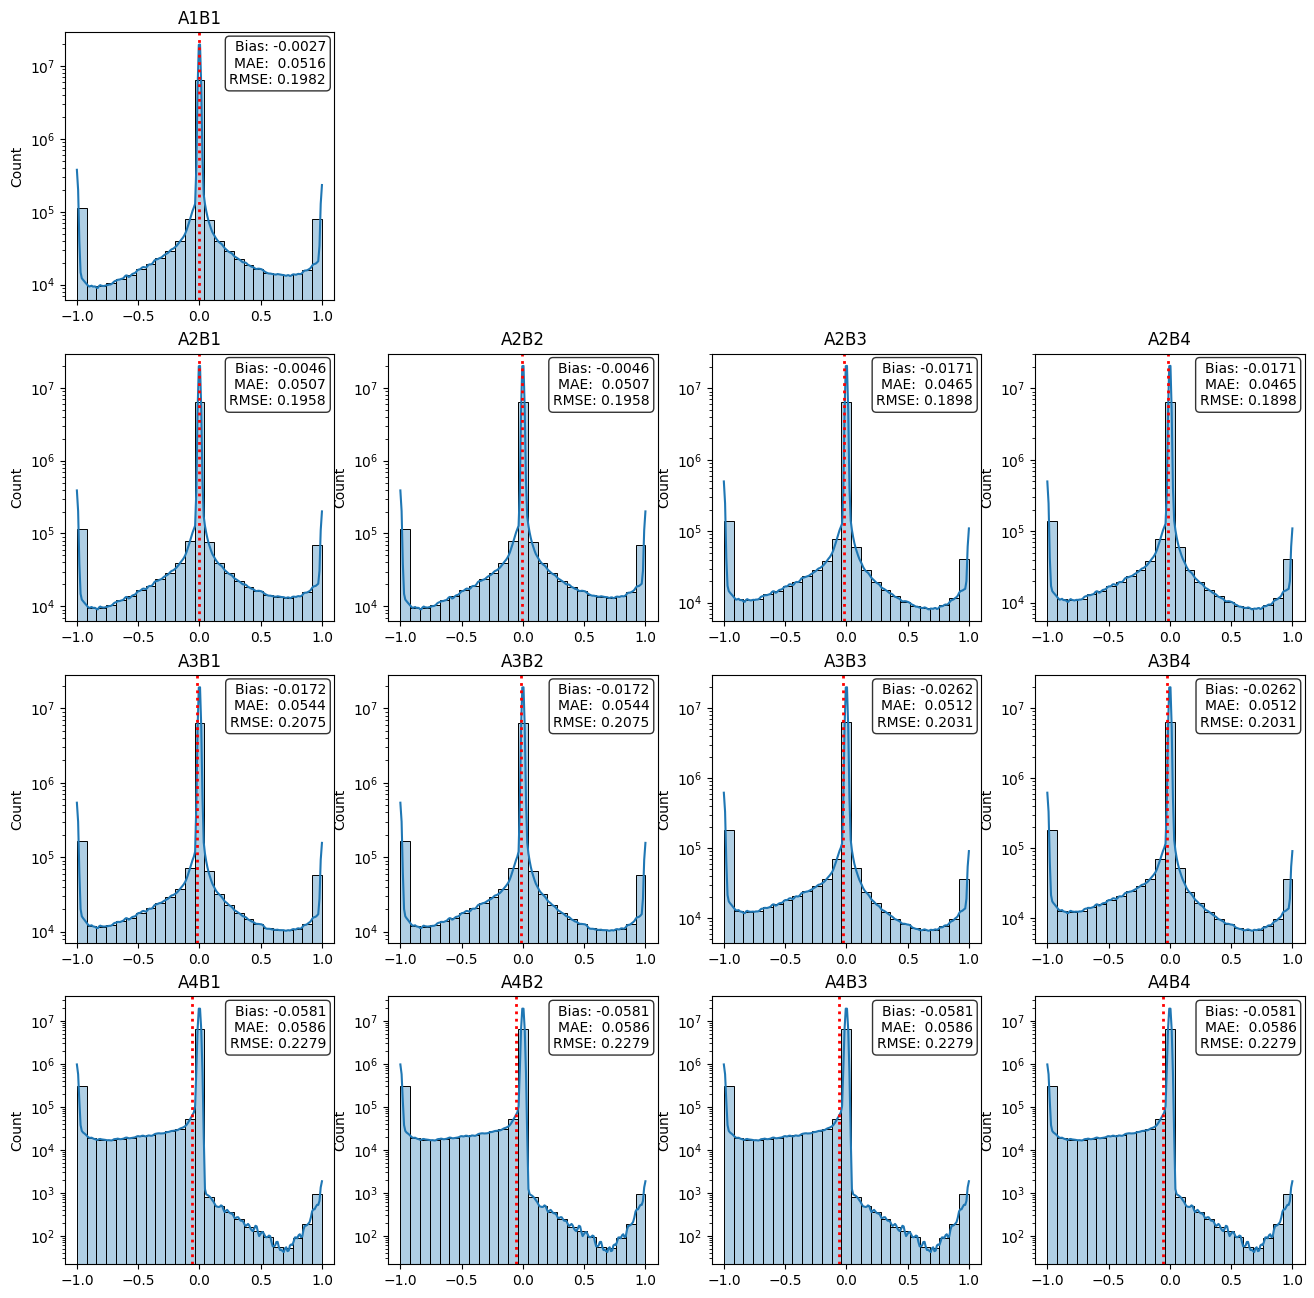

In [17]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16))

for experiment, values in data.items():
    row = int(experiment[1])
    col = int(experiment[3])
    ax = axs[row - 1, col - 1]

    residuals = values["metrics"]["residuals"]
    bias = values["metrics"]["Bias"]
    mae = values["metrics"]["MAE"]
    rmse = values["metrics"]["RMSE"]

    sns.histplot(
        residuals,
        bins=25,
        log_scale=(False, True),
        kde=True,
        ax=ax,
        stat="count",
        alpha=0.35,   # more transparency so KDE stands out
    )

    # Vertical dotted line for bias
    ax.axvline(
        bias,
        color="red",
        linestyle=":",
        linewidth=2,
        label="Bias",
    )

    ax.set_yscale("log", nonpositive="clip")

    # Info box inside the plot
    info_text = (
        f"Bias: {bias:.4f}\n"
        f"MAE:  {mae:.4f}\n"
        f"RMSE: {rmse:.4f}"
    )

    ax.text(
        0.97, 0.97,
        info_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.8,
        )
    )

    ax.set_title(experiment)

for ax in axs[0, 1:]:
    ax.set_visible(False)

plt.show()

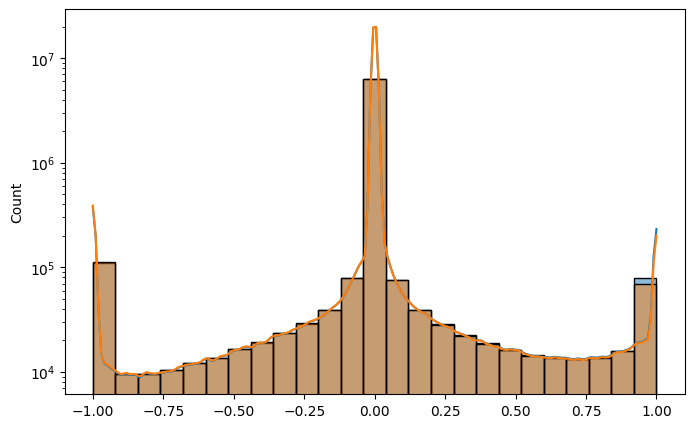

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(20, 20))

for experiment, values in data.items():
    row = int(experiment[1])
    col = int(experiment[3])
    ax = axs[row - 1, col - 1]

    sns.histplot(
        values["metrics"]["residuals"],
        bins=25,
        log_scale=(False, True),
        kde=True,
        ax=ax,
        stat="count",
    )
    sns.histplot(
        values["metrics"]["residuals"],
        bins=25,
        log_scale=(False, True),
        kde=False,
        ax=ax,
        stat="count",
    )

    ax.set_yscale("log", nonpositive="clip")


In [ ]:
results = {}
for experiment, metrics in data.items():
    results[experiment] = metrics["metrics"]


pd.DataFrame(results).T[["Bias", "MAE", "RMSE", "N"]]

,Bias,MAE,RMSE,N
A1B2,-0.002699,0.051605,0.198242,7078403
A2B2,-0.004578,0.050659,0.195801,7078403
A3B2,-0.017181,0.054413,0.20752,7078403
A4B2,-0.058075,0.058563,0.227905,7078403


## Run experiments - 1 site

In [107]:
from swot_toolkit.metrics import calc_metrics, process_swot_mask
from swot_toolkit.swot import create_raster_mosaic_combined
from swot_toolkit.pipe2 import open_output_dir, open_roi
from swot_toolkit.pipe4 import open_datasets

sites_dates = open_sites_and_dates("/data/swot/output")
sites_dates

{'Curua-Una': ['2024-07-13', '2025-08-14'],
 'Northeast': ['2024-05-29', '2025-07-20'],
 'Rio_Branco': ['2024-04-03', '2025-09-07'],
 'Rio_Madeira': ['2024-08-21', '2025-07-21'],
 'Rio_Negro': ['2024-11-29', '2025-08-07']}

In [88]:
REGION = "Curua-Una"
DATE = "2025-08-14"

In [89]:
datasets = open_datasets(REGION, DATE)

In [90]:
base_dir, aoi, mosaic_df = open_roi(REGION)

Reading KML file: /data/swot/output/Curua-Una/kml/Curua-Una.kml


In [101]:
params = get_filtering_params("No filtering", "Default filtering")

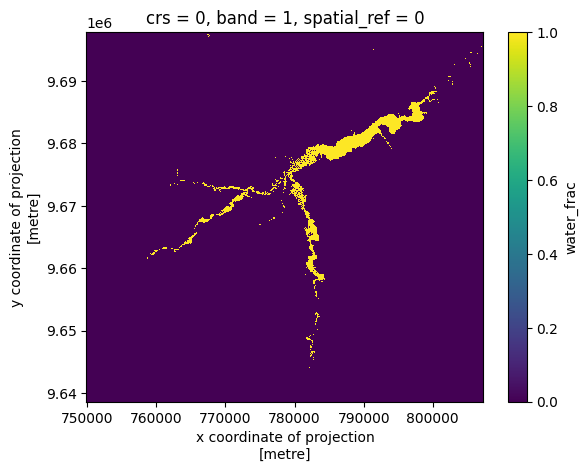

In [102]:
raster, patches, no_data_masks = create_raster_mosaic_combined(
    mosaic_df=mosaic_df,
    ref_date=DATE,
    aoi=aoi,
    **params,
)
raster = process_swot_mask(raster, water_threshold=0.6)
raster.plot()

In [103]:
metrics = ["iou", "f1", "precision", "recall"]
calc_metrics(datasets["ref_mask"], raster, metrics=metrics, binary=True)

,0
iou,0.7518
f1,0.8583
precision,0.9374
recall,0.7915


In [98]:
params = get_filtering_params("Bad removed", "Default filtering")

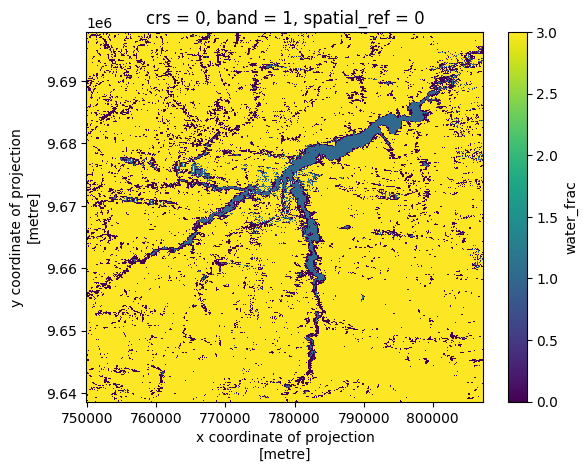

In [99]:
raster2, patches2, no_data_masks2 = create_raster_mosaic_combined(
    mosaic_df=mosaic_df,
    ref_date=DATE,
    aoi=aoi,
    **params,
)
raster2 = process_swot_mask(raster2, water_threshold=0.6)
raster2.plot()

In [100]:
metrics = ["iou", "f1", "precision", "recall"]
calc_metrics(datasets["ref_mask"], raster2, metrics=metrics, binary=True)

,0
iou,0.5837
f1,0.7371
precision,0.6484
recall,0.8540


## Run experiments

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

for region, dates in tqdm(sites_dates.items(), desc="Regions"):
    # Open basic info about the region
    base_dir, aoi, mosaic_df = open_roi(region)

    for date in dates:
        # Open datasets for the specific region and date
        datasets = open_datasets(region, date)

        metrics_df = pd.DataFrame()

        # Now, loop through the scenarios
        for i, scenario_a in enumerate(scenarios_A.keys()):
            for j, scenario_b in enumerate(scenarios_B.keys()):
                experiment_name = f"A{i + 1}B{j + 1}"
                params = get_filtering_params(scenario_a, scenario_b)

                raster, patches, no_data_masks = create_raster_mosaic_combined(
                    mosaic_df=mosaic_df,
                    ref_date=date,
                    aoi=aoi,
                    **params,
                )
                pred_mask = process_swot_mask(raster, water_threshold=0.59)

                stats = calc_metrics(
                    datasets["ref_mask"],
                    pred_mask,
                    metrics=metrics,
                    binary=True,
                )
                stats = stats.rename(columns={0: experiment_name})

                metrics_df = pd.concat([metrics_df, stats], axis=1)

        # After looping through all experiments, save the metrics for this region and date
        output_path = base_dir / date / "results"
        output_path.mkdir(parents=True, exist_ok=True)
        metrics_df.to_parquet(output_path / f"{region}_{date}_metrics.parquet")

Regions:   0%|          | 0/5 [00:00<?, ?it/s]

Reading KML file: /data/swot/output/Northeast/kml/Northeast.kml
Reading KML file: /data/swot/output/Rio_Branco/kml/Rio_Branco.kml


/workspaces/swot/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/swot/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/swot/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/swot/.venv/li

Reading KML file: /data/swot/output/Rio_Madeira/kml/Rio_Madeira.kml
Reading KML file: /data/swot/output/Rio_Negro/kml/Rio_Negro.kml


In [78]:
base_dir

PosixPath('/data/swot/output/Rio_Madeira')

In [79]:
metrics_df

,A1B1,A1B2,A1B3,A1B4,A2B1,A2B2,A2B3,A2B4,A3B1,A3B2,...,A2B3,A2B4,A3B1,A3B2,A3B3,A3B4,A4B1,A4B2,A4B3,A4B4
iou,0.7117,0.7117,0.7117,0.7117,0.4373,0.7548,0.6076,0.7475,0.4373,0.7548,...,0.2589,0.2593,0.2119,0.2297,0.2142,0.2298,0.0,0.0,0.0,0.0
f1,0.8315,0.8315,0.8315,0.8315,0.6085,0.8603,0.7559,0.8555,0.6085,0.8603,...,0.4113,0.4118,0.3497,0.3736,0.3528,0.3737,0.0,0.0,0.0,0.0
precision,0.9123,0.9123,0.9123,0.9123,0.4726,0.8785,0.6892,0.8835,0.4726,0.8785,...,0.3568,0.4434,0.3348,0.3908,0.3406,0.3912,0.0,0.0,0.0,0.0
recall,0.7639,0.7639,0.7639,0.7639,0.8544,0.8428,0.8369,0.8292,0.8544,0.8428,...,0.4855,0.3845,0.3659,0.3579,0.3659,0.3578,0.0,0.0,0.0,0.0


In [ ]:

        output_dir = f"output/analysis/scenario_A_{scenario_A.replace(' ', '_')}_B_{scenario_B.replace(' ', '_')}/"
        output_data = open_output_dir(output_dir)

        sites, dates = open_sites_and_dates(output_data)

        swot_metrics = {}
        for site in tqdm(sites, desc="Sites"):
            swot_metrics[site] = calc_swot_metrics(
                output_data,
                site,
                dates[site],
                exclude_flags=filtering_params["exclude_flags"],
                exclude_bitwise=filtering_params["exclude_bitwise"],
                exclude_geometric=filtering_params["exclude_geometric"],
            )

        output_data.close()

## Open sites and dates

In [ ]:
for A_name, A_filters in scenarios_A.items():
    for B_name, B_filters in scenarios_B.items():
        print(f"Processing Scenario A: {A_name} | Scenario B: {B_name}")
        for site_id, dates in tqdm(sites_dates.items()):
            output_dir = open_output_dir("/data/swot/output", site_id, dates)

            calc_swot_metrics(
                output_dir,
                exclude_flags=B_filters["excclude_flags"],
                exclude_no_data=B_filters["exclude_no_data"],
                exclude_water_area_qual=A_filters["exclude_water_area_qual"]
                if A_filters is not None
                else None,
                recompute=True,
            )